<a href="https://colab.research.google.com/github/Ansou94/projet-data-titanic/blob/main/Projet_titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

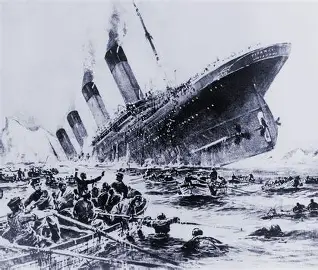
    
# **Projet Data Analyst**
# *Analyse des Survivants du Titanic*

---

**Réalisé par :** Ansoumana CISSE

**Date :** Mai 2026

**Outil :** Python — Google Colab

**Dataset :** [Kaggle - Titanic Dataset](https://www.kaggle.com/datasets/yasserh/titanic-dataset)

---

## 🎯 Objectif du projet

Le naufrage du Titanic est l'un des plus célèbres naufrages de l'histoire. Le **15 avril 1912**, le RMS Titanic a coulé lors de son voyage inaugural, causant la mort de **1 502 personnes** sur **2 224 passagers et membres d'équipage**.

L'objectif de ce projet est de répondre à la question suivante :

> **Quels profils de passagers avaient le plus de chances de survivre ?**

Pour la suite du projet, il est question de:
* Nettoyer les données,
* Explorer la base et visualiser,
* Tirer des conclusions concrètes.

C'est le projet idéal pour démarrer un portfolio de data analyst.
---

## 📋 Description des données

Le fichier contient **891 lignes** (passagers) et les colonnes suivantes :

| Colonne | Description |
|---|---|
| `PassengerId` | Identifiant unique du passager |
| `Survived` | 0 = décédé, 1 = survivant *(variable cible)* |
| `Pclass` | Classe du billet (1ère, 2ème ou 3ème classe) |
| `Name` | Nom complet du passager |
| `Sex` | Sexe du passager (male / female) |
| `Age` | Âge du passager *(contient des valeurs manquantes)* |
| `SibSp` | Nombre de frères/sœurs ou conjoints à bord |
| `Parch` | Nombre de parents ou enfants à bord |
| `Fare` | Prix du billet payé |
| `Embarked` | Port d'embarquement : C = Cherbourg, Q = Queenstown, S = Southampton |





## 🎯 Plan du projet

1. Chargement et exploration des données
2. Nettoyage des données
3. Analyse et visualisation
4. Conclusions

# 📌 **Étapes du projet**

## *Charger et explorer les données*

In [1]:
# Importer les packages nécessaires
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Charger le fichier (base de données)
#!pip install kaggle

In [3]:
from google.colab import files
files.upload()  # Sélectionne ton fichier kaggle.json

Saving Titanic-Dataset.csv to Titanic-Dataset.csv


{'Titanic-Dataset.csv': b'PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked\r\n1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.25,,S\r\n2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38,1,0,PC 17599,71.2833,C85,C\r\n3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.925,,S\r\n4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1,C123,S\r\n5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.05,,S\r\n6,0,3,"Moran, Mr. James",male,,0,0,330877,8.4583,,Q\r\n7,0,1,"McCarthy, Mr. Timothy J",male,54,0,0,17463,51.8625,E46,S\r\n8,0,3,"Palsson, Master. Gosta Leonard",male,2,3,1,349909,21.075,,S\r\n9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27,0,2,347742,11.1333,,S\r\n10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14,1,0,237736,30.0708,,C\r\n11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4,1,1,PP 9549,16.7,G6,S\r\n12,1,1,"Bonnell, Miss. Elizabeth",female,58,0,0,113783,26.55

In [4]:
titanic = pd.read_csv('Titanic-Dataset.csv')


In [5]:
#Afficher les 5 premières lignes
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
# Afficher le nombre de lignes et colonnes
titanic.shape

(891, 12)

In [7]:
# Renommer toutes les variables

titanic = titanic.rename(columns={
    'PassengerId' : 'id_passager',
    'Survived'    : 'survie',
    'Pclass'      : 'classe',
    'Name'        : 'nom',
    'Sex'         : 'sexe',
    'Age'         : 'age',
    'SibSp'       : 'freres_conjoints',
    'Parch'       : 'parents_enfants',
    'Fare'        : 'prix_billet',
    'Embarked'    : 'port_embarquement'
})

In [8]:
# Types de colonnes
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_passager        891 non-null    int64  
 1   survie             891 non-null    int64  
 2   classe             891 non-null    int64  
 3   nom                891 non-null    object 
 4   sexe               891 non-null    object 
 5   age                714 non-null    float64
 6   freres_conjoints   891 non-null    int64  
 7   parents_enfants    891 non-null    int64  
 8   Ticket             891 non-null    object 
 9   prix_billet        891 non-null    float64
 10  Cabin              204 non-null    object 
 11  port_embarquement  889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
# Statistiques descriptive des variables quantitatives
titanic.describe().T

,count,mean,std,min,25%,50%,75%,max
id_passager,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
survie,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
classe,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
freres_conjoints,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
parents_enfants,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
prix_billet,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


## *Nettoyer les données*

Vu que les données réelles sont rarement parfaites, nous allons proceder à au nettoyage de la base de données. c'est l'une des étapes essentielles pour un data analyst.

Nous allons également calculer le pourcentage de valeurs manquantes pour chaque variable, de supprimer celles qui ont plus de **20%** et de remplacer les celles qui ont moins de **20%** par leur médiane.

Dans notre cas, nous allons utiliser la méthode d'imputation par la médiane des variables **age**, **port_embarquement** et supprimer **Cabin**.

In [10]:
# Vérifier les valeurs manquantes et leur pourcentage
manquantes = titanic.isnull().sum()
pourcentage = (titanic.isnull().sum() / len(titanic)) * 100

# Afficher sous forme de tableau
resultat = pd.DataFrame({
    'Valeurs manquantes' : manquantes,
    'Pourcentage (%)'    : pourcentage.round(2)
})

print(resultat)

                   Valeurs manquantes  Pourcentage (%)
id_passager                         0             0.00
survie                              0             0.00
classe                              0             0.00
nom                                 0             0.00
sexe                                0             0.00
age                               177            19.87
freres_conjoints                    0             0.00
parents_enfants                     0             0.00
Ticket                              0             0.00
prix_billet                         0             0.00
Cabin                             687            77.10
port_embarquement                   2             0.22


In [11]:
# Remplir les valeurs manquantes de l'âges par la médiane (19,87%)
titanic['age'].fillna(titanic['age'].median(), inplace = True)

/tmp/ipykernel_1707/2728189889.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic['age'].fillna(titanic['age'].median(), inplace = True)


In [12]:
# Calculer et remplir les manquantes de port_embarquement par le mode (0,22%)
mode_port = titanic['port_embarquement'].mode()[0]
titanic['port_embarquement'].fillna(mode_port, inplace=True)

/tmp/ipykernel_1707/2482318777.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic['port_embarquement'].fillna(mode_port, inplace=True)


In [13]:
# Supprimer la colonne Cabin (trop de valeurs manquantes "77,10%")
titanic.drop(columns=['Cabin'], inplace=True)

In [14]:
# Revérification des valeurs manquantes
titanic.isna().sum()

,0
id_passager,0
survie,0
classe,0
nom,0
sexe,0
age,0
freres_conjoints,0
parents_enfants,0
Ticket,0
prix_billet,0


## Analyser et visualiser

C'est le cœur du projet. Nous allons créer des graphiques pour répondre à des questions d'analyse et comprendre le drame de titanic

In [15]:
# a) Taux de survie global
titanic['survie'].value_counts(normalize=True) * 100

,proportion
survie,
0,61.616162
1,38.383838


In [16]:
# Passagers total
total = len(titanic)
print("Passagers total :", total)

Passagers total : 891


In [17]:
# Survivants (Survived == 1)
survivants = titanic['survie'].sum()
print("Total survivants :", survivants)

Total survivants : 342


In [18]:
# Décédés (Survived == 0)
decedes = (titanic['survie'] == 0).sum()
print("Total décédés :", decedes)

Total décédés : 549


In [19]:
# Taux de survie
taux = (survivants / total) * 100
print(f"Taux de survie : {taux:.1f}%")

Taux de survie : 38.4%


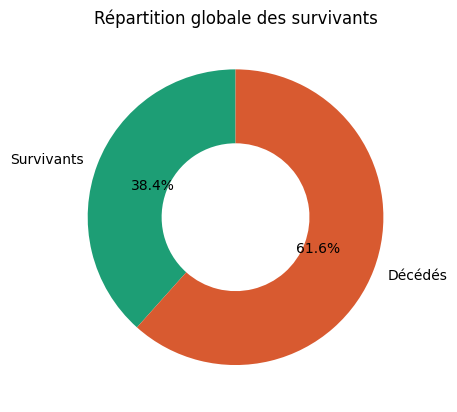

In [20]:
# Répartition des passager (Survivants vs Décédés)

labels = ['Survivants', 'Décédés']
sizes = [titanic['survie'].sum(), (titanic['survie'] == 0).sum()]
colors = ['#1D9E75', '#D85A30']
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90,
        wedgeprops=dict(width=0.5))
plt.title("Répartition globale des survivants")
plt.show()

**62% sont morts, 38% ont survécu.**

Le Titanic a été une catastrophe majeure : moins d'1 passager sur 2 a survécu. Cela pose immédiatement la question : **qui a survécu et pourquoi ?** Les graphiques suivants répondent à cette question.

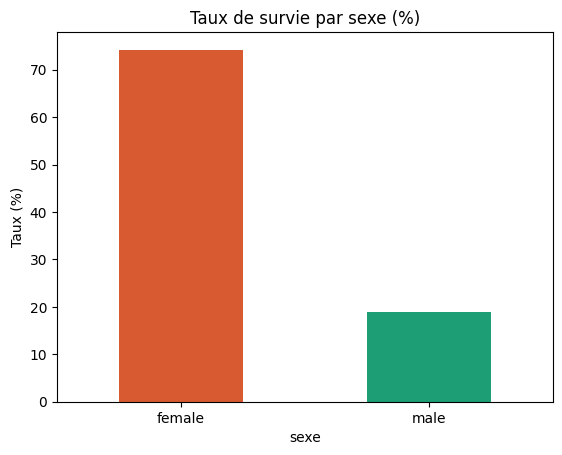

In [21]:
# Survie par sexe

survivant_sex = titanic.groupby('sexe')['survie'].mean() * 100
survivant_sex.plot(kind='bar', color=['#D85A30','#1D9E75'], edgecolor='none')
plt.title("Taux de survie par sexe (%)")
plt.ylabel("Taux (%)")
plt.xticks(rotation=0)
plt.show()


**Femmes : ~74% | Hommes : ~19%**

C'est la variable la plus déterminante du dataset. La règle **"les femmes et les enfants d'abord"** a été clairement appliquée lors de l'évacuation. Un homme avait environ **4 fois moins de chances** de survivre qu'une femme. C'est la corrélation la plus forte avec la survie.

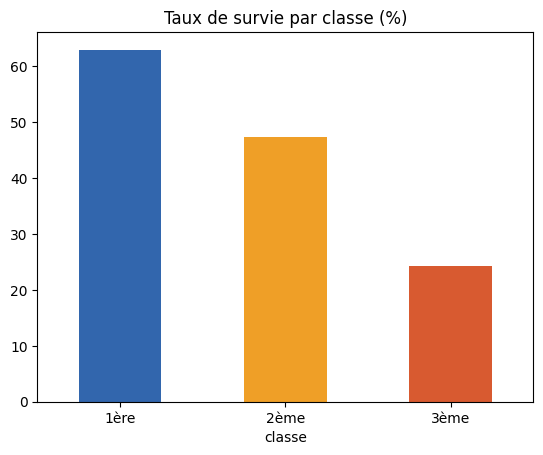

In [22]:
# Graphique 3 — Survie par classe

survivant_class = titanic.groupby('classe')['survie'].mean() * 100
survivant_class.plot(kind='bar', color=['#3266ad','#EF9F27','#D85A30'], edgecolor='none')
plt.title("Taux de survie par classe (%)")
plt.xticks([0,1,2], ['1ère','2ème','3ème'], rotation=0)
plt.show()

**1ère : ~63% | 2ème : ~47% | 3ème : ~24%**

La classe sociale a joué un rôle direct. Les passagers de 1ère classe avaient un accès prioritaire aux canots de sauvetage, leurs cabines étaient situées aux ponts supérieurs, donc plus proches des sorties. Les passagers de 3ème classe, logés en bas du navire, avaient **2,5 fois moins de chances** de survivre qu'en 1ère classe.

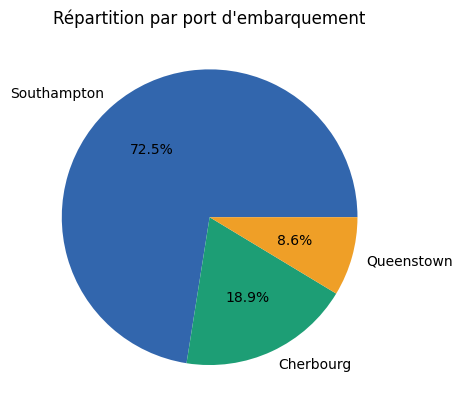

In [23]:
# Graphique 4 — Répartition par port d'embarquement

titanic['port_embarquement'].value_counts().plot(kind='pie', autopct='%1.1f%%',
    colors=['#3266ad','#1D9E75','#EF9F27'],
    labels=['Southampton','Cherbourg','Queenstown'])
plt.title("Répartition par port d'embarquement")
plt.ylabel("")
plt.show()

**Southampton : 72% | Cherbourg : 19% | Queenstown : 9%**

La grande majorité des passagers ont embarqué à Southampton (Angleterre). Cherbourg (France) représente 1 passager sur 5. Ce graphique est utile pour **croiser avec la survie** : les passagers de Cherbourg avaient un meilleur taux de survie car ils étaient proportionnellement plus nombreux en 1ère classe.

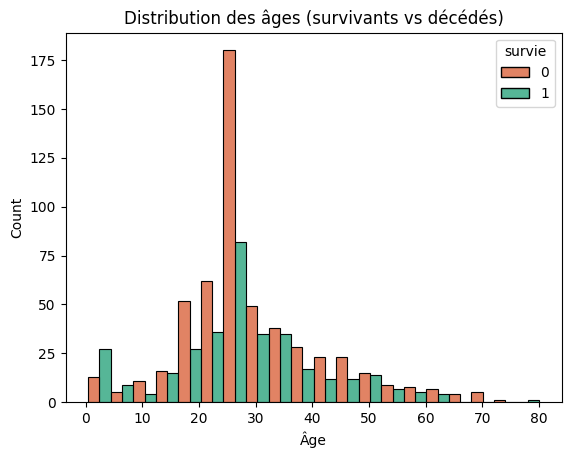

In [24]:
# Graphique 5 — Distribution des âges

sns.histplot(data=titanic, x='age', hue='survie', bins=20, multiple='dodge',
             palette={0:'#D85A30', 1:'#1D9E75'})
plt.title("Distribution des âges (survivants vs décédés)")
plt.xlabel("Âge")
plt.show()

Plusieurs observations importantes :

* Les **enfants de 0 à 9 ans** ont un ratio survivants/décédés favorable : la priorité leur a été donnée
* La **tranche 20-29 ans** concentre le plus grand nombre de décès en valeur absolue, simplement car c'est la tranche d'âge la plus représentée à bord
* Les **personnes âgées (60+)** ont très peu survécu, probablement à cause de leur mobilité réduite et de leur position en bas du navire

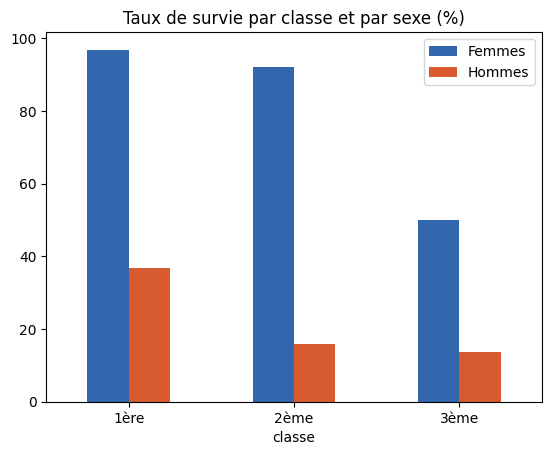

In [25]:
# Graphique 6 — Survie croisée sexe × classe

pivot = titanic.groupby(['classe','sexe'])['survie'].mean().unstack() * 100
pivot.plot(kind='bar', color=['#3266ad','#D85A30'], edgecolor='none')
plt.title("Taux de survie par classe et par sexe (%)")
plt.xticks([0,1,2], ['1ère','2ème','3ème'], rotation=0)
plt.legend(['Femmes','Hommes'])
plt.show()

C'est le graphique le plus riche en information combinée :

* **Femmes de 1ère classe : ~97%** → quasi toutes sauvées
* **Femmes de 2ème classe : ~92%** → presque autant
* **Femmes de 3ème classe : ~50%** → 1 chance sur 2 seulement
* **Hommes de 1ère classe : ~37%** → même riches, les hommes mouraient
* **Hommes de 2ème et 3ème classe : ~16-14%** → très peu de chances

Conclusion clé : être une femme sauvait, mais être pauvre annulait cet avantage en partie.

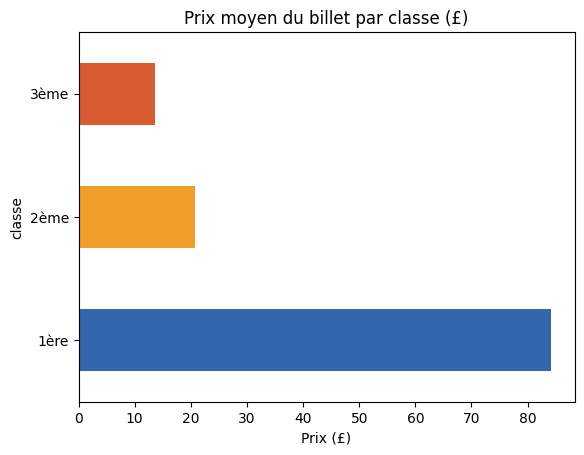

In [26]:
# Graphique 7 — Prix moyen du billet par classe

fare_class = titanic.groupby('classe')['prix_billet'].mean()
fare_class.plot(kind='barh', color=['#3266ad','#EF9F27','#D85A30'], edgecolor='none')
plt.title("Prix moyen du billet par classe (£)")
plt.yticks([0,1,2], ['1ère','2ème','3ème'])
plt.xlabel("Prix (£)")
plt.show()

**1ère : ~87£ | 2ème : ~21£ | 3ème : ~13£**

L'écart de prix est énorme entre la 1ère et les autres classes. Ce graphique confirme que **le niveau de richesse était directement lié à la position dans le navire**, et donc à l'accès aux canots. Le prix du billet est donc un proxy indirect de la survie.

/tmp/ipykernel_1707/3304414881.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survivant = titanic.groupby('AgeGroup')['survie'].mean() * 100


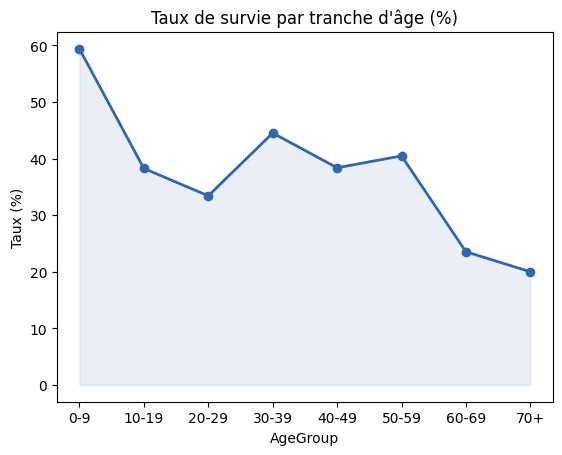

In [27]:
# Graphique 8 — Taux de survie par tranche d'âge

titanic['AgeGroup'] = pd.cut(titanic['age'], bins=[0,10,20,30,40,50,60,70,100],
                         labels=['0-9','10-19','20-29','30-39','40-49','50-59','60-69','70+'])
age_survivant = titanic.groupby('AgeGroup')['survie'].mean() * 100
age_survivant.plot(kind='line', marker='o', color='#3266ad', linewidth=2)
plt.fill_between(range(len(age_survivant)), age_survivant.values, alpha=0.1, color='#3266ad')
plt.title("Taux de survie par tranche d'âge (%)")
plt.ylabel("Taux (%)")
plt.xticks(range(len(age_survivant)), age_survivant.index)
plt.show()

* **0-9 ans : ~59%** → les enfants ont été prioritaires
* **10-39 ans : ~35-42%** → relativement stable
* **60-69 ans : ~27%** → forte chute
* **70+ ans : ~18%** → taux le plus bas

La courbe décroît globalement avec l'âge. Les très jeunes enfants ont bénéficié de la priorité d'évacuation, tandis que les personnes âgées ont été les plus vulnérables.

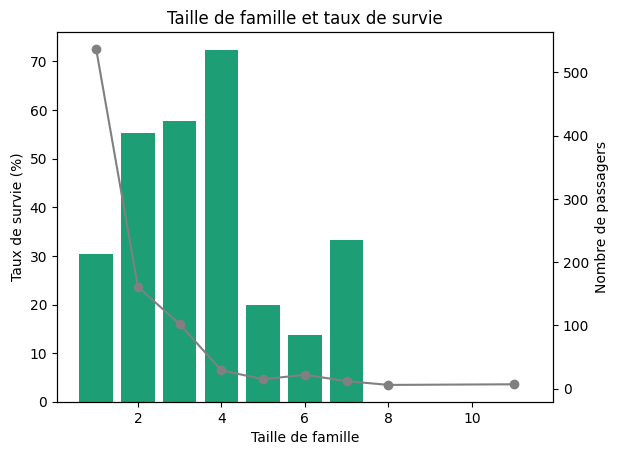

In [28]:
# Graphique 9 — Taille de famille et survie

titanic['taille_famille'] = titanic['freres_conjoints'] + titanic['parents_enfants'] + 1

family_stats = titanic.groupby('taille_famille').agg(
    taux_survie=('survie', 'mean'),
    nb_passagers=('survie', 'count')
).reset_index()

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.bar(family_stats['taille_famille'], family_stats['taux_survie']*100, color='#1D9E75')
ax2.plot(family_stats['taille_famille'], family_stats['nb_passagers'], color='gray', marker='o')
ax1.set_xlabel("Taille de famille")
ax1.set_ylabel("Taux de survie (%)")
ax2.set_ylabel("Nombre de passagers")
plt.title("Taille de famille et taux de survie")
plt.show()

**Familles de 2 à 4 personnes survivent le mieux (~55-72%)**

Deux axes sont superposés : les barres vertes = taux de survie, la courbe grise = nombre de passagers.

* **Les passagers seuls (taille = 1)** n'ont que 30% de chances de survie. Sans personne pour s'entraider, ils étaient désavantagés
* **Les petites familles (2-4)** ont le meilleur taux : elles étaient assez petites pour se déplacer rapidement, mais assez grandes pour se soutenir mutuellement
* **Les très grandes familles (5+)** voient leur taux chuter fortement : difficile d'évacuer tout le monde rapidement avec des enfants en bas âge
* La courbe grise montre que la majorité des passagers voyageaient **seuls (537 personnes)**, ce qui explique en partie le taux de mortalité global élevé

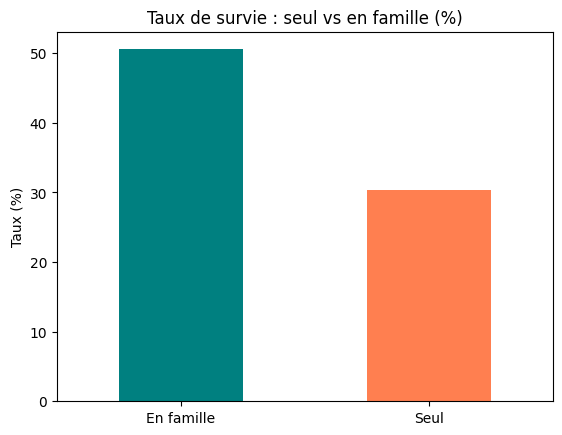

In [29]:
# Graphique 10 — Seul vs en famille

titanic['seul_famille'] = (titanic['taille_famille'] == 1).astype(int)

alone_survival = titanic.groupby('seul_famille')['survie'].mean() * 100
alone_survival.index = ['En famille', 'Seul']
alone_survival.plot(kind='bar', color=['teal', 'coral'], edgecolor='none')
plt.title("Taux de survie : seul vs en famille (%)")
plt.xticks(rotation=0)
plt.ylabel("Taux (%)")
plt.show()

**Seul : 30% | En famille : 51%**

Ce graphique confirme le précédent de manière binaire. Voyager avec de la famille augmentait les chances de survie de **+21 points**. L'entraide familiale lors de l'évacuation a clairement fait une différence : se repérer, porter les enfants, trouver les canots ensemble.

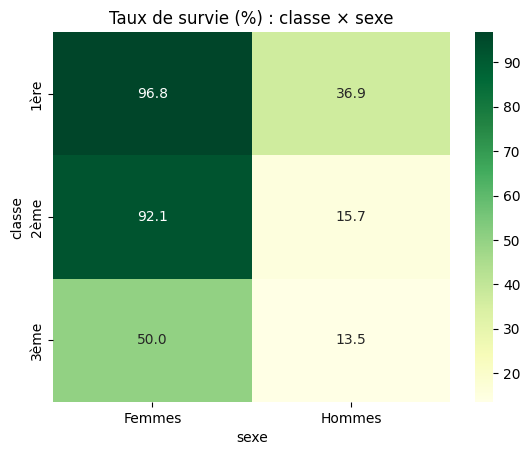

In [30]:
# Graphique 11 — Heatmap classe × sexe

pivot = titanic.pivot_table(values='survie', index='classe',
                        columns='sexe', aggfunc='mean') * 100
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlGn',
            xticklabels=['Femmes','Hommes'],
            yticklabels=['1ère','2ème','3ème'])
plt.title("Taux de survie (%) : classe × sexe")
plt.show()

C'est le graphique le plus instructif de cette série :

| Groupe | Taux de survie |
|---|---|
| 1ère / Femmes | 97% |
| 2ème / Femmes | 92% |
| 1ère / Hommes | 37% |
| 3ème / Femmes | 50% |
| 2ème / Hommes | 16% |
| 3ème / Hommes | 14% |

La lecture est frappante : une femme de 1ère classe avait **97% de chances de survivre**, tandis qu'un homme de 3ème classe n'en avait que **14%**. L'écart entre le groupe le plus favorisé et le moins favorisé est de **83 points.** Le sexe et la classe combinés créent des inégalités dramatiques face à la mort.


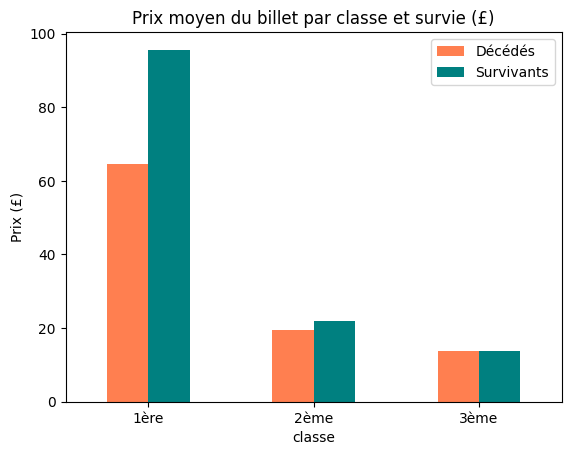

In [31]:
# Graphique 12 — Prix du billet par classe et survie

prix_billet_survivant = titanic.groupby(['classe','survie'])['prix_billet'].mean().unstack()
prix_billet_survivant.columns = ['Décédés','Survivants']
prix_billet_survivant.plot(kind='bar', color=['coral', 'teal'], edgecolor='none')
plt.title("Prix moyen du billet par classe et survie (£)")
plt.xticks([0,1,2], ['1ère','2ème','3ème'], rotation=0)
plt.ylabel("Prix (£)")
plt.show()

**Les survivants avaient payé beaucoup plus cher leur billet**

* En **1ère classe**, les survivants ont payé en moyenne ~106£ contre ~52£ pour les décédés : même au sein de la même classe, ceux qui avaient les billets les plus chers (donc les meilleures cabines, plus hautes dans le navire) survivaient davantage
* En **2ème et 3ème classe**, l'écart est beaucoup plus faible car les prix étaient homogènes
* Ce graphique montre que **la richesse individuelle, même à classe égale, influençait la survie.**

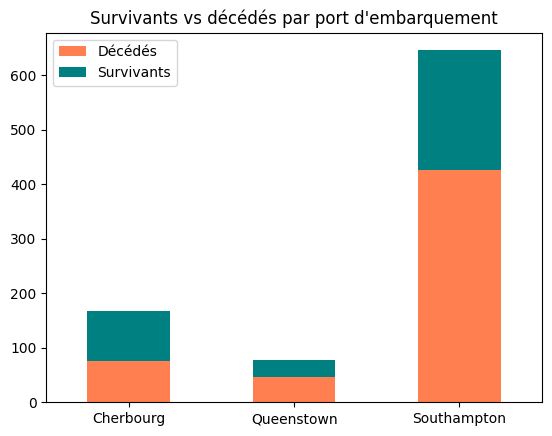

In [32]:
# Graphique 13 — Port d'embarquement × survie (barres empilées)

embark_survivant = titanic.groupby(['port_embarquement','survie']).size().unstack()
embark_survivant.columns = ['Décédés','Survivants']
embark_survivant.index = ['Cherbourg','Queenstown','Southampton']
embark_survivant.plot(kind='bar', stacked=True,
                     color=['coral', 'teal'], edgecolor='none')
plt.title("Survivants vs décédés par port d'embarquement")
plt.xticks(rotation=0)
plt.show()

**Southampton : le plus de morts en valeur absolue | Cherbourg : meilleur ratio**

* **Southampton** concentre le plus grand nombre de passagers (644), donc aussi le plus grand nombre de décès en absolu. Mais en proportion, son taux de survie est le plus faible
* **Cherbourg** présente le meilleur taux de survie relatif car ses passagers étaient majoritairement des voyageurs de **1ère classe** (riches européens)
* **Queenstown** avait surtout des immigrants irlandais en **3ème classe**, ce qui explique son taux de survie plus faible malgré un petit effectif

Ce graphique illustre que le port n'est pas en lui-même la cause, c'est **le profil socio-économique** des passagers qui embarquaient dans chaque port qui explique les différences.

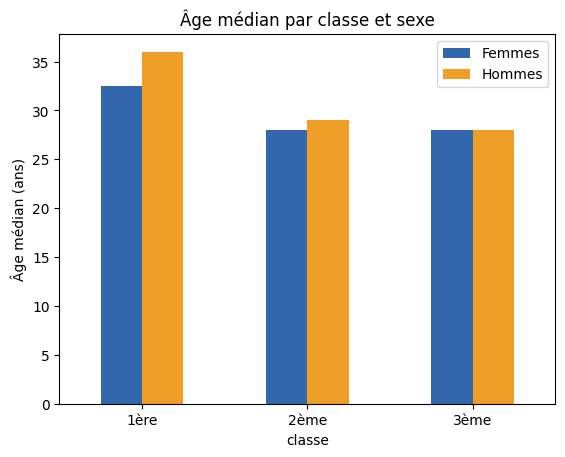

In [33]:
# Graphique 14 — Âge médian par classe et sexe

age_profile = titanic.groupby(['classe','sexe'])['age'].median().unstack()
age_profile.columns = ['Femmes','Hommes']
age_profile.plot(kind='bar', color=['#3266ad', '#EF9F27'], edgecolor='none')
plt.title("Âge médian par classe et sexe")
plt.xticks([0,1,2], ['1ère','2ème','3ème'], rotation=0)
plt.ylabel("Âge médian (ans)")
plt.show()

**Les passagers de 1ère classe étaient significativement plus âgés**

* **1ère classe :** femmes ~37 ans, hommes ~42 ans → des personnes établies, en milieu ou fin de carrière
* **2ème classe :** femmes ~28 ans, hommes ~30 ans → profil intermédiaire
* **3ème classe :** femmes ~22 ans, hommes ~25 ans → très jeunes, souvent des immigrants cherchant une nouvelle vie en Amérique

Ce graphique permet de comprendre la **composition démographique** du navire. Les passagers de 3ème classe étaient jeunes mais pauvres, ce qui explique que leur jeunesse ne les a pas sauvés face au désavantage de leur position dans le navire.

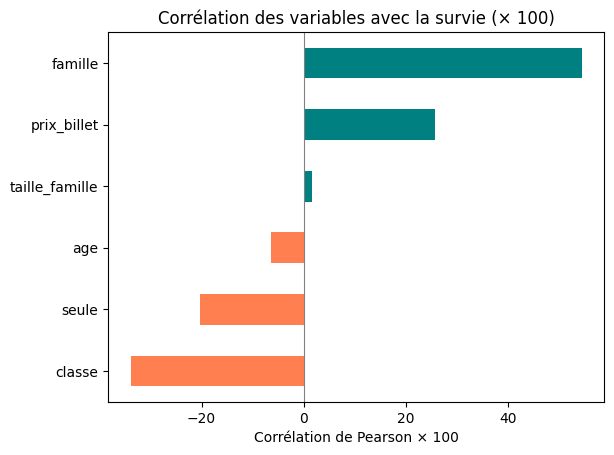

In [34]:
# Graphique 15 — Corrélations avec la survie
titanic['famille'] = (titanic['sexe'] == 'female').astype(int)
titanic['seule'] = (titanic['taille_famille'] == 1).astype(int)

cols = ['famille','classe','prix_billet','age','taille_famille','seule']
correlations = titanic[cols].corrwith(titanic['survie']) * 100

correlations.sort_values().plot(kind='barh',
    color=['teal' if v > 0 else 'coral' for v in correlations.sort_values()])
plt.axvline(0, color='gray', linewidth=0.8)
plt.title("Corrélation des variables avec la survie (× 100)")
plt.xlabel("Corrélation de Pearson × 100")
plt.show()

C'est le graphique le plus analytique : il quantifie l'influence de chaque variable sur la survie.

| Variable | Corrélation | Sens |
| --- | ---| --- |
| Sexe (female) | +54 | Être une femme = fort avantage |
| Classe (Pclass) | -34 | Classe élevée = avantage (échelle inversée) |
| Tarif (Fare) | +26 | Billet cher = avantage |
|Seul/famille | +20| Voyager en famille = avantage |
| Taille famille | +17 | Légèrement positif |
|Âge | -7 | Être jeune = léger avantage |

**Lectures clés :**

* Le **sexe** est de loin le facteur numéro 1 avec +54, presque le double de la classe sociale
* La **classe** et le tarif vont dans le même sens : plus on est riche, plus on survit
* L'**âge** a une influence très faible (-7), ce qui est surprenant mais s'explique par des effets contraires qui se compensent (enfants favorisés, mais 3ème classe très jeune et défavorisée)